In [1]:
import sys
print(sys.executable)

c:\Users\nandh\OneDrive\Desktop\predictive maintenance\venv\Scripts\python.exe


In [2]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Machine failure"].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [9]:
df["Machine failure"].value_counts(normalize=True) * 100


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
failure_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df[failure_columns].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [12]:
df[failure_columns + ["Machine failure"]].corr()

,TWF,HDF,PWF,OSF,RNF,Machine failure
TWF,1.000000,-0.007332,0.008577,0.038243,0.030970,0.362904
HDF,-0.007332,1.000000,0.018443,0.046396,-0.004706,0.575800
PWF,0.008577,0.018443,1.000000,0.115836,-0.004273,0.522812
OSF,0.038243,0.046396,0.115836,1.000000,-0.004341,0.531083
RNF,0.030970,-0.004706,-0.004273,-0.004341,1.000000,0.004516
Machine failure,0.362904,0.575800,0.522812,0.531083,0.004516,1.000000


In [13]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [14]:
df["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

In [15]:
df["UDI"].nunique()

10000

In [16]:
df["Product ID"].nunique()

10000

In [17]:
pd.crosstab(df["Type"], df["Machine failure"])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [18]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[feature_columns]
y = df["Machine failure"]

In [19]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [20]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [21]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 6)
Target: (10000,)


In [22]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [23]:
X = df[feature_columns]
y = df["Machine failure"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (8000, 6)
Testing set: (2000, 6)

Training target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Testing target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (8000, 8)
Testing data shape: (2000, 8)


In [28]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numerical_features].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


Matplotlib is building the font cache; this may take a moment.


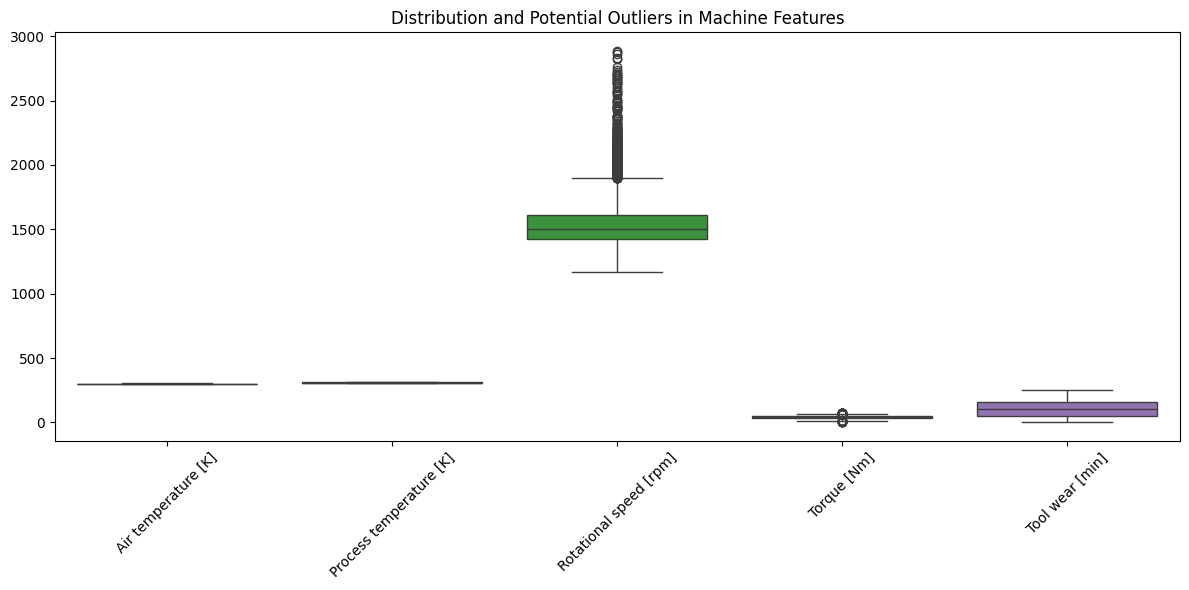

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_features])
plt.xticks(rotation=45)
plt.title("Distribution and Potential Outliers in Machine Features")
plt.tight_layout()
plt.show()

In [30]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (8000, 8)
Processed testing shape: (2000, 8)


In [31]:
print(y_train.value_counts())
print(y_test.value_counts())

Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [32]:
failure_counts = df["Machine failure"].value_counts()

print(failure_counts)

Machine failure
0    9661
1     339
Name: count, dtype: int64


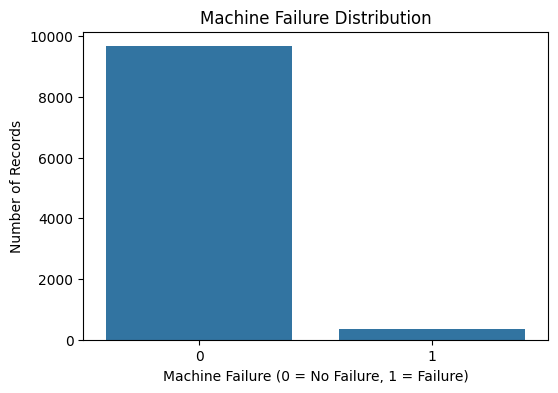

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Records")
plt.show()

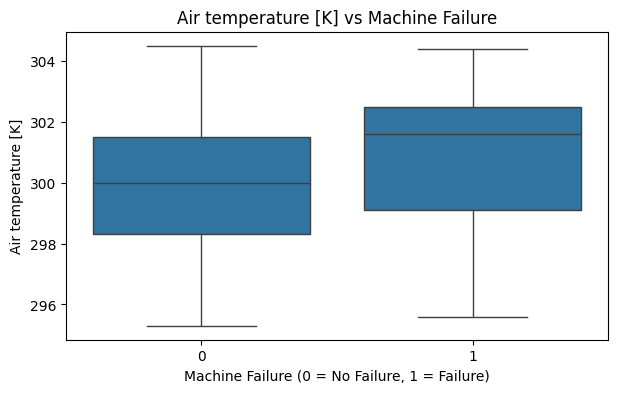

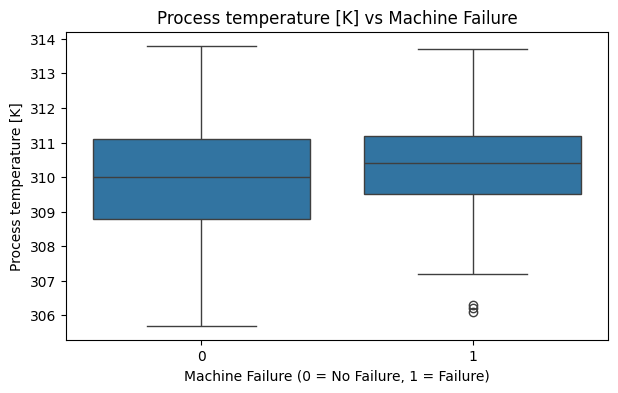

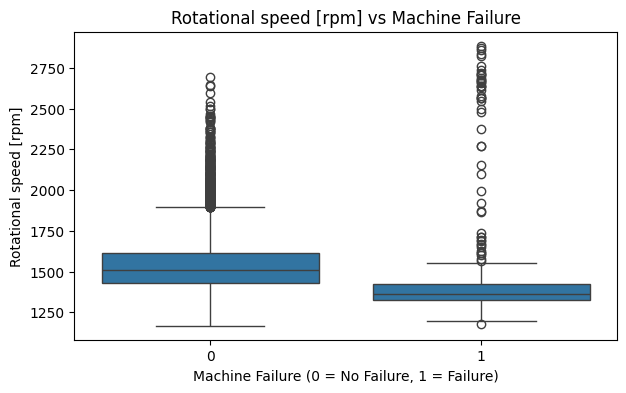

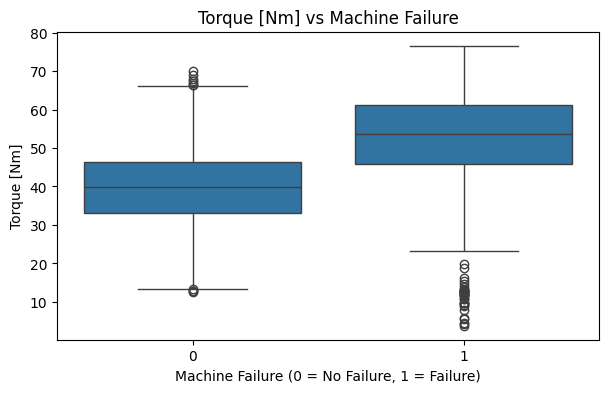

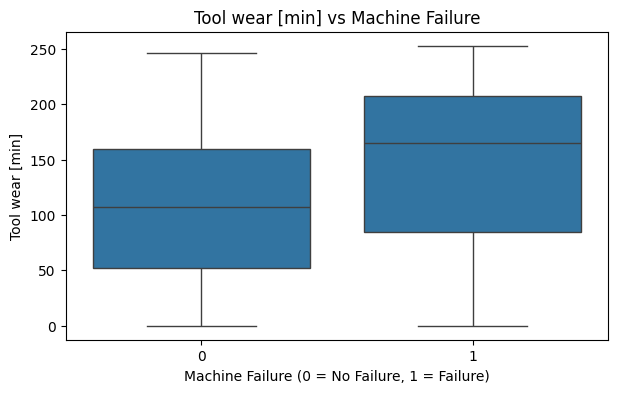

In [34]:
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="Machine failure", y=feature, data=df)
    plt.title(f"{feature} vs Machine Failure")
    plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
    plt.ylabel(feature)
    plt.show()

In [35]:
failure_by_type = pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

failure_by_type

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


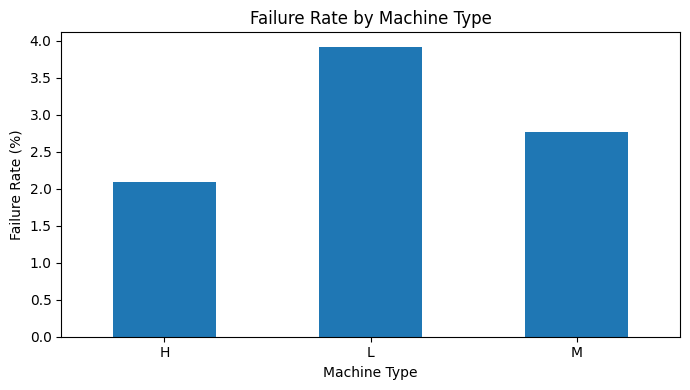

In [36]:
plt.figure(figsize=(7, 4))

failure_by_type[1].plot(kind="bar")

plt.title("Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
correlation = df[numerical_features + ["Machine failure"]].corr()

correlation

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


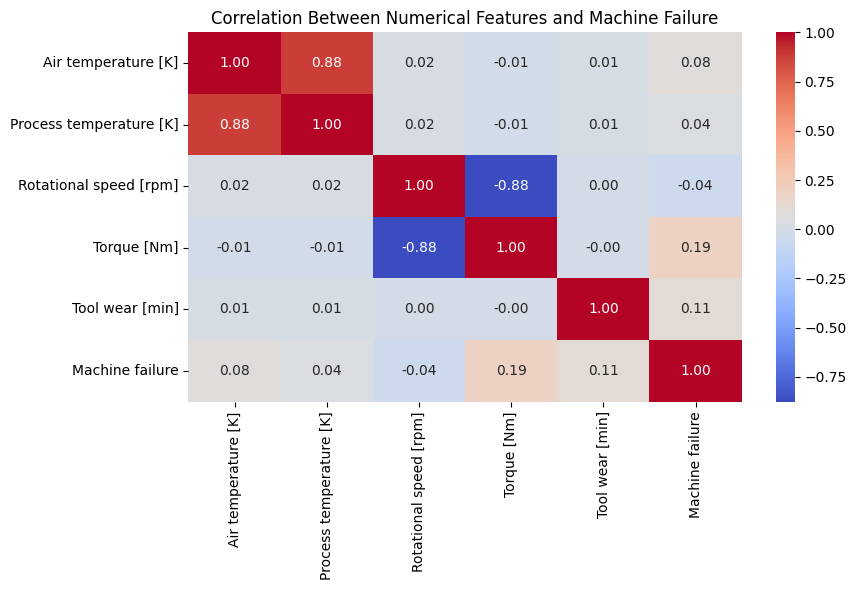

In [38]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features and Machine Failure")
plt.tight_layout()
plt.show()

In [39]:
df_fe = df.copy()

df_fe["Temperature_Difference"] = (
    df_fe["Process temperature [K]"] -
    df_fe["Air temperature [K]"]
)

df_fe["Mechanical_Power"] = (
    df_fe["Torque [Nm]"] *
    df_fe["Rotational speed [rpm]"]
)

df_fe.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature_Difference,Mechanical_Power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0


In [40]:
df_fe[
    [
        "Temperature_Difference",
        "Mechanical_Power"
    ]
].describe()

,Temperature_Difference,Mechanical_Power
count,10000.000000,10000.000000
mean,10.000630,59967.147040
std,1.001094,10193.093881
min,7.600000,10966.800000
25%,9.300000,53105.400000
50%,9.800000,59883.900000
75%,11.000000,66873.750000
max,12.100000,99980.400000


In [41]:
feature_columns_fe = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature_Difference",
    "Mechanical_Power"
]

In [42]:
X = df_fe[feature_columns_fe]
y = df_fe["Machine failure"]

In [43]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 8)
Target: (10000,)


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature_Difference",
    "Mechanical_Power"
]

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [48]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [49]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.9675

Confusion Matrix:
[[1923    9]
 [  56   12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.57      0.18      0.27        68

    accuracy                           0.97      2000
   macro avg       0.77      0.59      0.63      2000
weighted avg       0.96      0.97      0.96      2000



In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [53]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.991

Confusion Matrix:
[[1929    3]
 [  15   53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [56]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [57]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.99

Confusion Matrix:
[[1929    3]
 [  17   51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.75      0.84        68

    accuracy                           0.99      2000
   macro avg       0.97      0.87      0.92      2000
weighted avg       0.99      0.99      0.99      2000



In [60]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))
print("PR-AUC:", average_precision_score(y_test, y_prob_logistic))

print("\nRandom Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

print("\nXGBoost")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

Logistic Regression
ROC-AUC: 0.925739861161856
PR-AUC: 0.46218699860481605

Random Forest
ROC-AUC: 0.9697052734137133
PR-AUC: 0.8766267129692707

XGBoost
ROC-AUC: 0.9796385945682622
PR-AUC: 0.891552569395216


In [61]:
logistic_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [62]:
logistic_balanced_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
y_pred_logistic_balanced = logistic_balanced_pipeline.predict(X_test)

y_prob_logistic_balanced = (
    logistic_balanced_pipeline.predict_proba(X_test)[:, 1]
)

In [64]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic_balanced))

Accuracy: 0.8585

Confusion Matrix:
[[1658  274]
 [   9   59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [65]:
random_forest_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [66]:
random_forest_balanced_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
y_pred_rf_balanced = random_forest_balanced_pipeline.predict(X_test)

y_prob_rf_balanced = (
    random_forest_balanced_pipeline.predict_proba(X_test)[:, 1]
)

In [68]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_balanced))

Accuracy: 0.988

Confusion Matrix:
[[1929    3]
 [  21   47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [69]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative samples: 7729
Positive samples: 271
scale_pos_weight: 28.52029520295203


In [70]:
xgb_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [71]:
xgb_balanced_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
y_pred_xgb_balanced = xgb_balanced_pipeline.predict(X_test)

y_prob_xgb_balanced = (
    xgb_balanced_pipeline.predict_proba(X_test)[:, 1]
)

In [73]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_balanced))

Accuracy: 0.975

Confusion Matrix:
[[1888   44]
 [   6   62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.58      0.91      0.71        68

    accuracy                           0.97      2000
   macro avg       0.79      0.94      0.85      2000
weighted avg       0.98      0.97      0.98      2000



In [74]:
print("Balanced Logistic Regression")
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_logistic_balanced)
)
print(
    "PR-AUC:",
    average_precision_score(y_test, y_prob_logistic_balanced)
)

print("\nBalanced Random Forest")
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf_balanced)
)
print(
    "PR-AUC:",
    average_precision_score(y_test, y_prob_rf_balanced)
)

print("\nBalanced XGBoost")
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb_balanced)
)
print(
    "PR-AUC:",
    average_precision_score(y_test, y_prob_xgb_balanced)
)

Balanced Logistic Regression
ROC-AUC: 0.933952928997686
PR-AUC: 0.4658798217383025

Balanced Random Forest
ROC-AUC: 0.9662685726464499
PR-AUC: 0.8533609013227691

Balanced XGBoost
ROC-AUC: 0.977568201193521
PR-AUC: 0.8880945251812119


In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models_results = {
    "Logistic Regression": (
        y_pred_logistic,
        y_prob_logistic
    ),
    "Random Forest": (
        y_pred_rf,
        y_prob_rf
    ),
    "XGBoost": (
        y_pred_xgb,
        y_prob_xgb
    ),
    "Balanced Logistic Regression": (
        y_pred_logistic_balanced,
        y_prob_logistic_balanced
    ),
    "Balanced Random Forest": (
        y_pred_rf_balanced,
        y_prob_rf_balanced
    ),
    "Balanced XGBoost": (
        y_pred_xgb_balanced,
        y_prob_xgb_balanced
    )
}

results = []

for model_name, (predictions, probabilities) in models_results.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.968,0.571,0.176,0.270,0.926,0.462
1,Random Forest,0.991,0.946,0.779,0.855,0.970,0.877
2,XGBoost,0.990,0.944,0.750,0.836,0.980,0.892
3,Balanced Logistic Regression,0.858,0.177,0.868,0.294,0.934,0.466
4,Balanced Random Forest,0.988,0.940,0.691,0.797,0.966,0.853
5,Balanced XGBoost,0.975,0.585,0.912,0.713,0.978,0.888


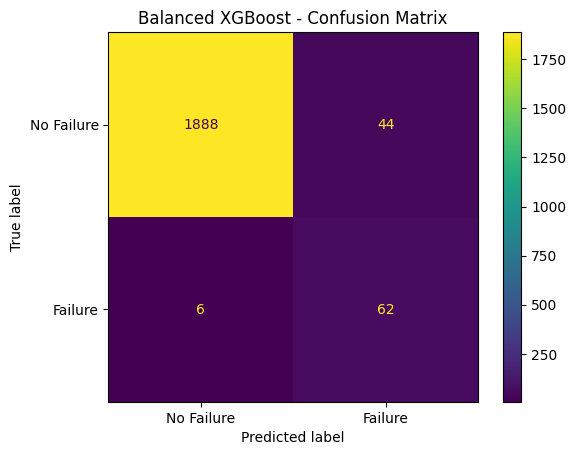

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_balanced,
    display_labels=["No Failure", "Failure"]
)

plt.title("Balanced XGBoost - Confusion Matrix")
plt.show()

In [77]:
precision = precision_score(y_test, y_pred_xgb_balanced)
recall = recall_score(y_test, y_pred_xgb_balanced)
f1 = f1_score(y_test, y_pred_xgb_balanced)

print("Failure Precision:", round(precision, 3))
print("Failure Recall:", round(recall, 3))
print("Failure F1-Score:", round(f1, 3))

Failure Precision: 0.585
Failure Recall: 0.912
Failure F1-Score: 0.713


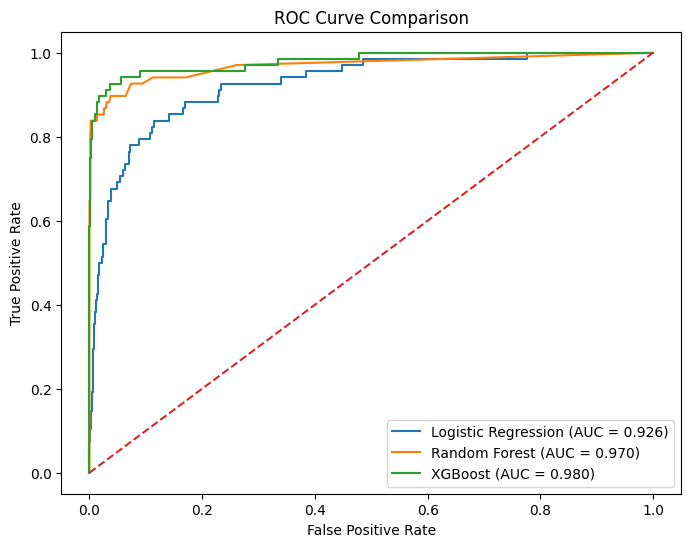

In [78]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

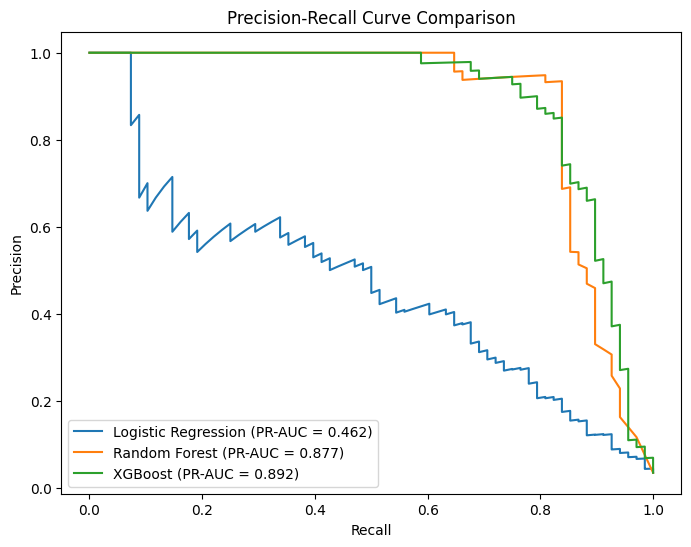

In [79]:
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test, y_prob_logistic
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test, y_prob_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test, y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (PR-AUC = {average_precision_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_test, y_prob_xgb):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [80]:
import shap

# Get the trained XGBoost model
xgb_model = xgb_balanced_pipeline.named_steps["model"]

# Get the preprocessing step
xgb_preprocessor = xgb_balanced_pipeline.named_steps["preprocessor"]

# Transform test data
X_test_transformed = xgb_preprocessor.transform(X_test)

# Convert to dense format if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get feature names after preprocessing
feature_names = xgb_preprocessor.get_feature_names_out()

print(feature_names)

['categorical__Type_H' 'categorical__Type_L' 'categorical__Type_M'
 'numerical__Air temperature [K]' 'numerical__Process temperature [K]'
 'numerical__Rotational speed [rpm]' 'numerical__Torque [Nm]'
 'numerical__Tool wear [min]' 'numerical__Temperature_Difference'
 'numerical__Mechanical_Power']


In [82]:
import shap
import xgboost

print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)

SHAP version: 0.49.1
XGBoost version: 3.2.0


In [84]:
xgb_model = xgb_balanced_pipeline.named_steps["model"]

booster = xgb_model.get_booster()

print(type(booster))

<class 'xgboost.core.Booster'>


In [86]:
import pandas as pd

importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
5,numerical__Rotational speed [rpm],0.247894
9,numerical__Mechanical_Power,0.172729
7,numerical__Tool wear [min],0.167693
6,numerical__Torque [Nm],0.164203
8,numerical__Temperature_Difference,0.096529
3,numerical__Air temperature [K],0.045000
4,numerical__Process temperature [K],0.033064
2,categorical__Type_M,0.029031
1,categorical__Type_L,0.025384
0,categorical__Type_H,0.018474


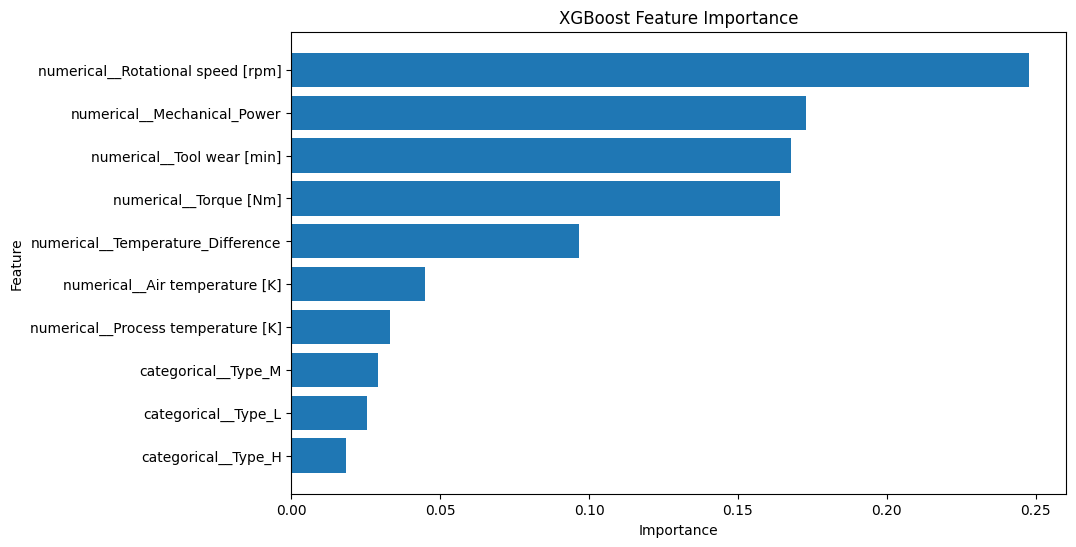

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [88]:
y_prob_xgb_balanced[:10]

array([0.3952824 , 0.00228968, 0.58601016, 0.00308902, 0.09194078,
       0.01412702, 0.19318537, 0.00303977, 0.00095883, 0.02562948],
      dtype=float32)

In [89]:
def calculate_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

In [90]:
print(calculate_risk(0.15))
print(calculate_risk(0.50))
print(calculate_risk(0.85))

Low Risk
Medium Risk
High Risk


In [91]:
risk_results = pd.DataFrame({
    "Actual Failure": y_test.values,
    "Failure Probability": y_prob_xgb_balanced
})

risk_results["Risk Level"] = risk_results["Failure Probability"].apply(
    calculate_risk
)

risk_results["Failure Probability"] = (
    risk_results["Failure Probability"] * 100
).round(2)

risk_results.head(10)

,Actual Failure,Failure Probability,Risk Level
0,0,39.529999,Medium Risk
1,0,0.230000,Low Risk
2,0,58.599998,Medium Risk
3,0,0.310000,Low Risk
4,0,9.190000,Low Risk
5,0,1.410000,Low Risk
6,0,19.320000,Low Risk
7,0,0.300000,Low Risk
8,0,0.100000,Low Risk
9,0,2.560000,Low Risk


In [92]:
risk_results["Risk Level"].value_counts()

Risk Level
Low Risk       1840
High Risk        82
Medium Risk      78
Name: count, dtype: int64

In [93]:
import joblib

joblib.dump(
    xgb_balanced_pipeline,
    "../models/xgb_balanced_pipeline.pkl"
)

print("Model saved successfully!")

Model saved successfully!
